# <center>第一次作业</center>
## <center>金桐宇 BZ25219005</center>

### 1 相关性分析

=== 各特征与混凝土抗压强度(csMPa)的绝对相关性排序 ===
cement              : 绝对值 0.4978 (原始值: 0.4978)
superplasticizer    : 绝对值 0.3661 (原始值: 0.3661)
age                 : 绝对值 0.3289 (原始值: 0.3289)
water               : 绝对值 0.2896 (原始值: -0.2896)
fineaggregate       : 绝对值 0.1672 (原始值: -0.1672)
coarseaggregate     : 绝对值 0.1649 (原始值: -0.1649)
slag                : 绝对值 0.1348 (原始值: 0.1348)
flyash              : 绝对值 0.1058 (原始值: -0.1058)


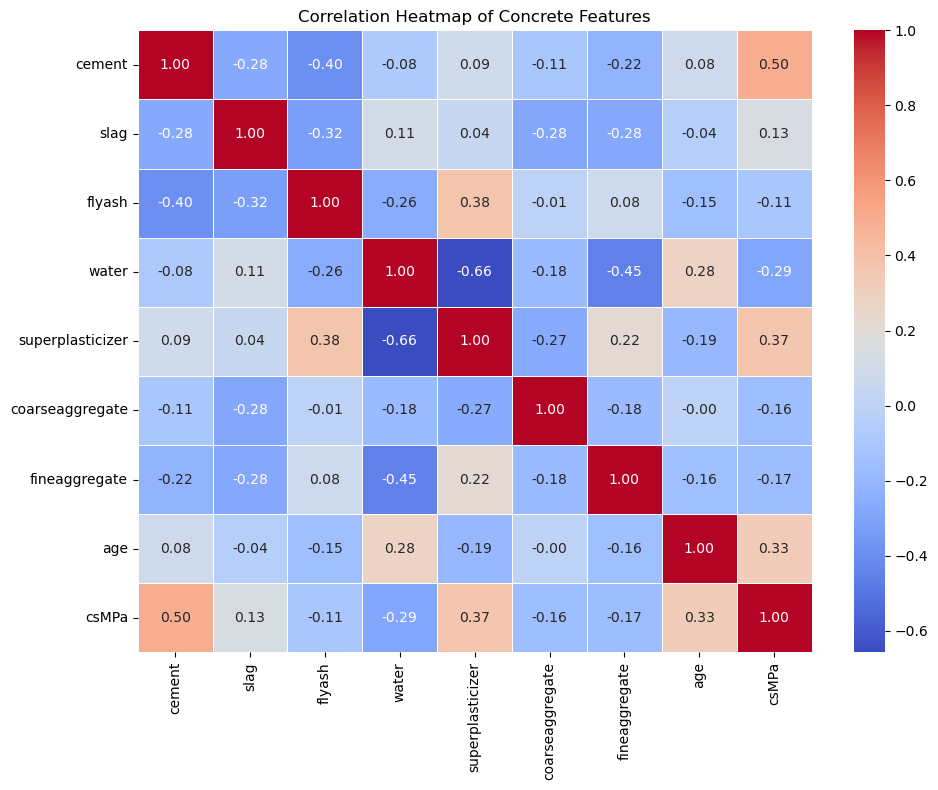


基于阈值 0.2 选择的主要特征: ['cement', 'superplasticizer', 'age', 'water']


In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 读取数据集
df = pd.read_csv('Concrete_Data_Yeh.csv')

# 2. 计算所有变量之间的皮尔逊相关系数矩阵
correlation_matrix = df.corr()

# 3. 单独提取各特征与输出变量 (csMPa) 的相关性
# drop('csMPa') 是为了把目标变量自己和自己的相关性(1.0)去掉
target_corr = correlation_matrix['csMPa'].drop('csMPa')

# 按照相关性的绝对值从大到小排序，方便寻找最重要的特征
target_corr_sorted = target_corr.abs().sort_values(ascending=False)

print("=== 各特征与混凝土抗压强度(csMPa)的绝对相关性排序 ===")
for feature, corr_value in target_corr_sorted.items():
    # 获取原始的正负号相关性值
    original_val = target_corr[feature]
    print(f"{feature:20s}: 绝对值 {corr_value:.4f} (原始值: {original_val:.4f})")

# 4. 绘制相关性热力图可视化全貌
plt.figure(figsize=(10, 8)).canvas.manager.set_window_title('Figure 2')
# annot=True 显示具体数值, cmap='coolwarm' 提供红蓝冷暖色调对比
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Concrete Features')
plt.tight_layout()
plt.show()

# 5. 特征选择（示例：选择绝对相关性大于 0.1 的特征）
threshold = 0.2
selected_features = target_corr_sorted[target_corr_sorted > threshold].index.tolist()
print(f"\n基于阈值 {threshold} 选择的主要特征: {selected_features}")

运行结果如下：\
=== 各特征与混凝土抗压强度(csMPa)的绝对相关性排序 ===\
cement              : 绝对值 0.4978 (原始值: 0.4978)\
superplasticizer    : 绝对值 0.3661 (原始值: 0.3661)\
age                 : 绝对值 0.3289 (原始值: 0.3289)\
water               : 绝对值 0.2896 (原始值: -0.2896)\
fineaggregate       : 绝对值 0.1672 (原始值: -0.1672)\
coarseaggregate     : 绝对值 0.1649 (原始值: -0.1649)\
slag                : 绝对值 0.1348 (原始值: 0.1348)\
flyash              : 绝对值 0.1058 (原始值: -0.1058)\
![Figure_1.png](Figures/Figure_1.png)\
基于阈值 0.2 选择的主要特征: ['cement', 'superplasticizer', 'age', 'water']

根据热力图所示，cement（水泥）相关性最高，为正相关0.50，superplasticizer（高效减水剂）为正相关0.37，age（养护龄期为）正相关0.33，water（水）为负相关-0.29，这四个因变量即特征作为主要特征，其余四个特征相关性绝对值均小于0.2，排除在外。

### 2 主成分分析

=== 各主成分的方差解释率 ===
主成分 1: 0.2850 (28.50%)
主成分 2: 0.1770 (17.70%)
主成分 3: 0.1675 (16.75%)
主成分 4: 0.1268 (12.68%)
主成分 5: 0.1189 (11.89%)
主成分 6: 0.0988 (9.88%)
主成分 7: 0.0222 (2.22%)
主成分 8: 0.0038 (0.38%)

=== 累积方差解释率 ===
前 1 个主成分累积解释: 0.2850 (28.50%)
前 2 个主成分累积解释: 0.4620 (46.20%)
前 3 个主成分累积解释: 0.6295 (62.95%)
前 4 个主成分累积解释: 0.7563 (75.63%)
前 5 个主成分累积解释: 0.8752 (87.52%)
前 6 个主成分累积解释: 0.9740 (97.40%)
前 7 个主成分累积解释: 0.9962 (99.62%)
前 8 个主成分累积解释: 1.0000 (100.00%)


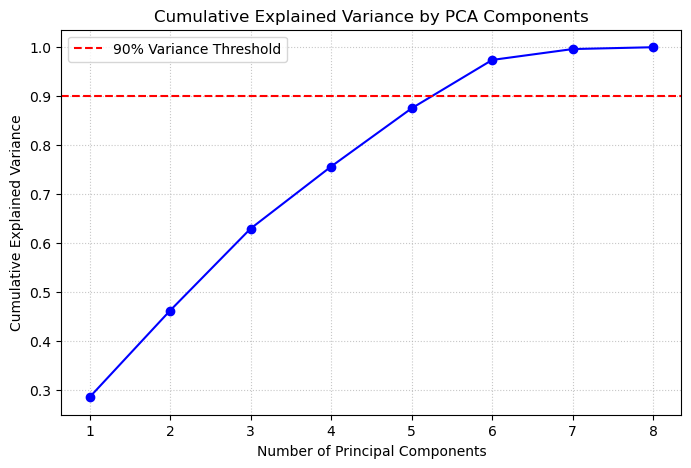


为了保留至少 90% 的方差，我们需要提取前 6 个主成分。
降维后的输入数据矩阵维度: (1030, 6)


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. 读取数据并分离输入与输出
df = pd.read_csv('Concrete_Data_Yeh.csv')
X = df.iloc[:, :8].values  # 原始 8 个输入特征
y = df.iloc[:, 8].values   # 输出：抗压强度

# 2. 数据标准化 (PCA 的关键前置步骤)
# 确保每个特征的均值为 0，方差为 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. 拟合 PCA 模型 (初始保留所有 8 个成分以观察方差分布)
pca = PCA(n_components=8)
pca.fit(X_scaled)

# 4. 获取方差解释率
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

print("=== 各主成分的方差解释率 ===")
for i, ratio in enumerate(explained_variance_ratio):
    print(f"主成分 {i+1}: {ratio:.4f} ({ratio*100:.2f}%)")

print("\n=== 累积方差解释率 ===")
for i, cum_ratio in enumerate(cumulative_variance_ratio):
    print(f"前 {i+1} 个主成分累积解释: {cum_ratio:.4f} ({cum_ratio*100:.2f}%)")

# 5. 绘制累积方差解释率折线图
plt.figure(figsize=(8, 5))
plt.plot(range(1, 9), cumulative_variance_ratio, marker='o', linestyle='-', color='b')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Variance Threshold')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.xticks(range(1, 9))
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

# 6. 执行降维 (假设我们选择保留 90% 的方差)
# 从上面的输出和图表中，你可以决定保留多少个成分，通常取累积方差 > 0.90 或 0.95 的 k 值
k = np.argmax(cumulative_variance_ratio >= 0.95) + 1 
print(f"\n为了保留至少 90% 的方差，我们需要提取前 {k} 个主成分。")

pca_final = PCA(n_components=k)
X_pca_reduced = pca_final.fit_transform(X_scaled)

print(f"降维后的输入数据矩阵维度: {X_pca_reduced.shape}")

运行结果如下：\
=== 各主成分的方差解释率 ===\
主成分 1: 0.2850 (28.50%)\
主成分 2: 0.1770 (17.70%)\
主成分 3: 0.1675 (16.75%)\
主成分 4: 0.1268 (12.68%)\
主成分 5: 0.1189 (11.89%)\
主成分 6: 0.0988 (9.88%)\
主成分 7: 0.0222 (2.22%)\
主成分 8: 0.0038 (0.38%)

=== 累积方差解释率 ===
前 1 个主成分累积解释: 0.2850 (28.50%)\
前 2 个主成分累积解释: 0.4620 (46.20%)\
前 3 个主成分累积解释: 0.6295 (62.95%)\
前 4 个主成分累积解释: 0.7563 (75.63%)\
前 5 个主成分累积解释: 0.8752 (87.52%)\
前 6 个主成分累积解释: 0.9740 (97.40%)\
前 7 个主成分累积解释: 0.9962 (99.62%)\
前 8 个主成分累积解释: 1.0000 (100.00%)\
![Figure_2.png](Figures/Figure_2.png)

为了保留至少 95% 的方差，我们需要提取前 6 个主成分。\
降维后的输入数据矩阵维度: (1030, 6)

如图所示，选择前6个主成分，舍弃剩下2个主成分可以解释95%以上的方差。

### 3 线性回归

#### 3.1 直接使用线性回归

Epoch [1000/5000], Loss: 848.5229
Epoch [2000/5000], Loss: 471.5810
Epoch [3000/5000], Loss: 257.1767
Epoch [4000/5000], Loss: 156.1721
Epoch [5000/5000], Loss: 123.1608

Final Test Mean Squared Error (MSE): 82.8559


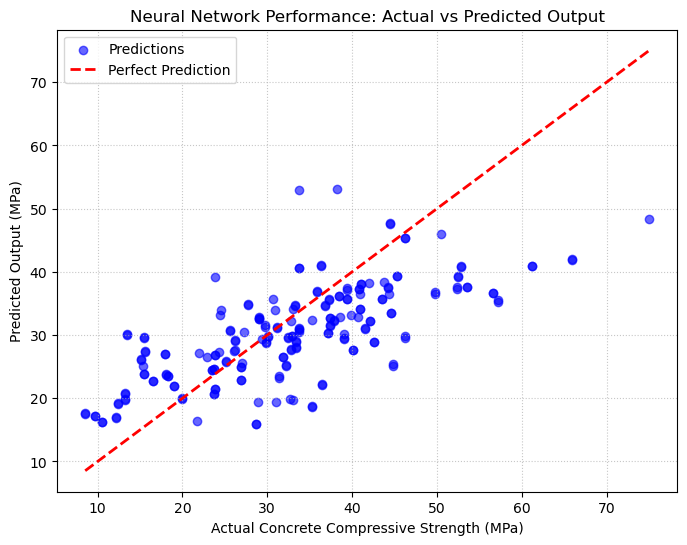

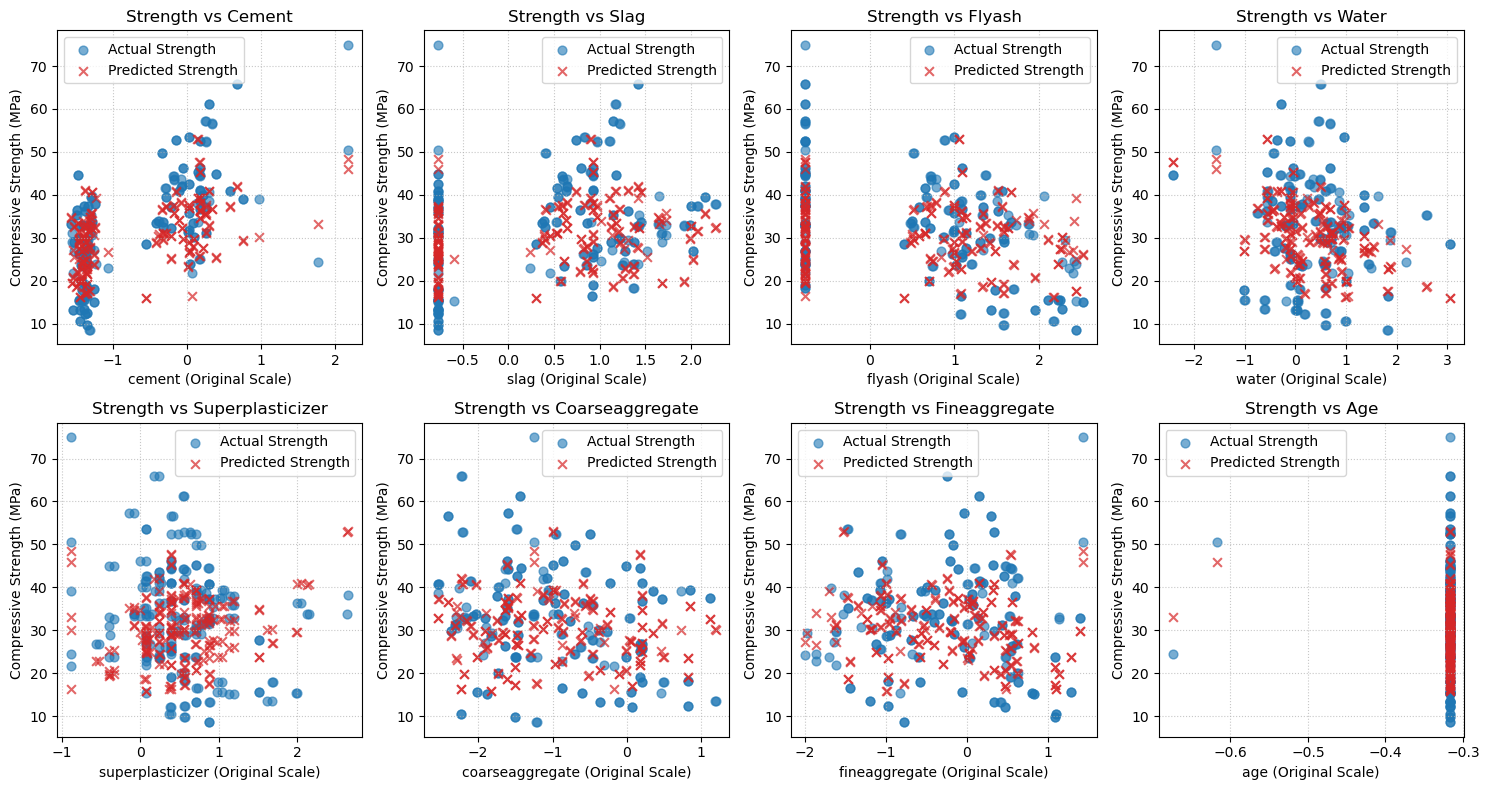

In [3]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from plot import plot

# ==========================================
# 步骤 1 & 2: 数据准备与预处理
# ==========================================

# 读取数据集
df = pd.read_csv('Concrete_Data_Yeh.csv')

# 提取8个输入变量和1个输出变量
# iloc方法是通过索引行、列的索引位置[index, columns]来寻找值
# 第一个参数为行，第二个参数为列
# csv文件的第一行为标签，不计入，df.iloc[0]即表示第2行的数据
X = df.iloc[:, :8].values  # 前8列为输入特征
y = df.iloc[:, 8].values.reshape(-1, 1)  # 第9列为输出特征 (抗压强度)
# 这里不加.values好像也行，加了返回array
# reshape把行向量转变为列向量，相当于转置
# 这是因为iloc[:, 8]破坏了列维度，使用iloc[:, 8:9]或iloc[:, 8:]即可保留列维度，不需要reshape

# a) 数据准备：将数据集的前80%作为训练集，后20%作为测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
# 将shuffle置否即可实现前80%后20%的分割方法

# b) 数据预处理：使用标准化处理特征，确保输入数据在相同的量纲维度下，加速模型收敛
scaler = StandardScaler()
# StandardScaler 是一种常用的数据标准化方法，用于将数据转换为均值为 0，标准差为 1 的标准正态分布
X_train_scaled = scaler.fit_transform(X_train)
# fit_transform 不仅计算训练数据的均值和方差，还会基于计算出来的均值和方差来转换训练数据
X_test_scaled = scaler.transform(X_test)
# transform 很显然，它只是进行转换，只是把测试数据转换成标准的正态分布。在fit的基础上，进行标准化
# 一般来说测试集使用fit_transform验证集使用transform
# 在测试集时已经收集了数据的均值和方差并且我们认为测试集和验证集数据收集的都足够充分，均值和方差一致，所以验证集不需要重新求均值和方差

# 将 NumPy 数组转换为 PyTorch 的 Tensor 格式
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)
# 经典pytorch，明显是要上模型了

# ==========================================
# 步骤 3: 线性回归模型构建 (核心修改部分)
# ==========================================

# c) 构建线性回归模型
class LinearRegressionNet(nn.Module):
    def __init__(self):
        super(LinearRegressionNet, self).__init__()
        # 线性回归不需要隐藏层和激活函数，直接从输入层(8)映射到输出层(1)
        # 这就等同于 y = w1*x1 + w2*x2 + ... + w8*x8 + b
        self.linear = nn.Linear(8, 1)

    def forward(self, x): # 前向传播
        return self.linear(x)

model = LinearRegressionNet()
# 实例化 LinearRegressionNet

# 使用均方误差 (MSE) 作为损失函数
criterion = nn.MSELoss()

# 使用 Adam 优化器 (对于标准线性回归也可以用 optim.SGD 随机梯度下降)
# lr (learning rate) 是学习率，决定每次参数更新的步长大小
optimizer = optim.Adam(model.parameters(), lr=0.01)

# ==========================================
# 步骤 4: 模型训练
# ==========================================

# d) 使用训练集对模型进行训练，通过反向传播算法更新权重和偏置
epochs = 5000
# 当一个完整的数据集通过了神经网络一次并且返回了一次，这个过程称为一次epoch
train_losses = []

for epoch in range(epochs):
    model.train()
    # 开始训练模型
    optimizer.zero_grad()           # 清空梯度

    outputs = model(X_train_t)      # 前向传播
    loss = criterion(outputs, y_train_t) # 计算损失

    loss.backward()                 # 反向传播，计算当前梯度
    optimizer.step()                # 根据梯度更新权重参数 (w 和 b)

    train_losses.append(loss.item())
    # item()函数的主要用途是从单元素张量中提取元素值并返回

    if (epoch + 1) % 1000 == 0:
        # 每 100 epoch
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

# ==========================================
# 步骤 5: 模型测试、评估与可视化
# ==========================================

# e) 使用测试集评估模型，计算预测值与实际值之间的均方误差
model.eval() # 切换至评估模式
with torch.no_grad():
    # torch.no_grad 是 PyTorch 中的一个上下文管理器，它的主要作用是在某个指定的代码块中禁用梯度计算。
    # 这在进行模型推理或评估时非常有用，因为在这些情况下，我们通常不需要计算梯度，从而可以减少内存消耗和计算时间
    predictions = model(X_test_t)
    test_mse = criterion(predictions, y_test_t)

print(f"\nFinal Test Mean Squared Error (MSE): {test_mse.item():.4f}")

# 调用外部 plot 函数进行绘图
plot(X_test_t, y_test_t, predictions, df.columns[:8].tolist())

一次运行结果如下：

Epoch [1000/5000], Loss: 879.3002\
Epoch [2000/5000], Loss: 491.9418\
Epoch [3000/5000], Loss: 268.5943\
Epoch [4000/5000], Loss: 160.9594\
Epoch [5000/5000], Loss: 124.3187

Final Test Mean Squared Error (MSE): 84.0659

![Figure_3.png](Figures/Figure_3.png)

![Figure_4.png](Figures/Figure_4.png)

如上图所示，第一张图为实际值为横轴，预测值为纵轴绘制的散点图，但并不是非常直观。第二张图为以每个输入特征即因变量为横轴，实际值和预测值为纵轴绘制的散点图，分别用蓝点和红叉表示，发现对于每个输入特征无论是实际值还是预测值都出现了大量同样的横轴值对应多个不同的纵轴值的情况，导致无法绘制折线图，这是因为有些数据点可能某个输入特征相同但其他输入特征不同，导致产生了不同的输出，对分析产生了更大的难度。

#### 3.2 高相关性特征的线性回归

In [ ]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from plot import plot

# ==========================================
# 步骤 1 & 2: 数据准备与预处理 (基于筛选特征)
# ==========================================

# 读取数据集
df = pd.read_csv('Concrete_Data_Yeh.csv')

# --- 修改点：基于相关性分析筛选的特征列表 ---
selected_features = ['cement', 'superplasticizer', 'age', 'water']
print(f"使用的主要特征: {selected_features}")

# 提取筛选后的输入变量 X 和 输出变量 y
# 使用 df[selected_features] 直接按列名提取
X = df[selected_features].values
y = df.iloc[:, 8].values.reshape(-1, 1)  # 假设抗压强度依然在第9列

# a) 数据准备：前80%作为训练集，后20%作为测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# b) 数据预处理：标准化
# 此时 scaler 仅针对这 4 个特征进行计算
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 将 NumPy 数组转换为 PyTorch 的 Tensor 格式
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

# ==========================================
# 步骤 3: 线性回归模型构建 (输入维度改为 4)
# ==========================================

class LinearRegressionNet(nn.Module):
    def __init__(self):
        super(LinearRegressionNet, self).__init__()
        # 注意：这里的输入维度从 8 变成了 4
        self.linear = nn.Linear(4, 1)

    def forward(self, x):
        return self.linear(x)

model = LinearRegressionNet()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# ==========================================
# 步骤 4: 模型训练 (代码逻辑不变)
# ==========================================

epochs = 5000
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)

    loss.backward()
    optimizer.step()

    if (epoch + 1) % 1000 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

# ==========================================
# 步骤 5: 模型评估与可视化
# ==========================================

model.eval()
with torch.no_grad():
    predictions = model(X_test_t)
    test_mse = criterion(predictions, y_test_t)

print(f"\nFinal Test Mean Squared Error (MSE) with 4 features: {test_mse.item():.4f}")

# 可视化时，特征名称列表传入筛选后的列表
plot(X_test_t, y_test_t, predictions, selected_features)

运行结果如下：

使用的主要特征: ['cement', 'superplasticizer', 'age', 'water']\
Epoch [1000/5000], Loss: 866.2073\
Epoch [2000/5000], Loss: 493.7789\
Epoch [3000/5000], Loss: 282.9204\
Epoch [4000/5000], Loss: 184.0952\
Epoch [5000/5000], Loss: 152.1058

Final Test Mean Squared Error (MSE) with 4 features: 125.3641


![Figure_5.png](Figures/Figure_5.png)

![Figure_6.png](Figures/Figure_6.png)

发现相对3.1并没有多少提升。

#### 3.3 主成分分析后的线性回归

In [ ]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA  # 导入 PCA 模块
from plot import plot

# ==========================================
# 步骤 1 & 2: 数据准备、标准化与 PCA 降维
# ==========================================

# 读取数据集
df = pd.read_csv('Concrete_Data_Yeh.csv')

X = df.iloc[:, :8].values  # 原始 8 个特征
y = df.iloc[:, 8].values.reshape(-1, 1)

# a) 数据分割：先分割，再在训练集上寻找主成分
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# b) 数据预处理：必须先进行标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 核心修改：PCA 降维 ---
# 选择前 6 个主成分
n_components = 6
pca = PCA(n_components=n_components)

# 在训练集上拟合 PCA 并在训练/测试集上应用转换
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"原始特征维度: {X_train_scaled.shape[1]}")
print(f"PCA 降维后维度: {X_train_pca.shape[1]}")
print(f"前 {n_components} 个主成分解释的总方差比例: {sum(pca.explained_variance_ratio_):.4f}")

# 将处理后的数据转换为 Tensor
X_train_t = torch.tensor(X_train_pca, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test_pca, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

# ==========================================
# 步骤 3: 线性回归模型构建 (输入维度改为 6)
# ==========================================

class LinearRegressionNet(nn.Module):
    def __init__(self):
        super(LinearRegressionNet, self).__init__()
        # 现在的输入维度是 PCA 处理后的 6 个分量
        self.linear = nn.Linear(n_components, 1)

    def forward(self, x):
        return self.linear(x)

model = LinearRegressionNet()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# ==========================================
# 步骤 4: 模型训练
# ==========================================

epochs = 5000
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)

    loss.backward()
    optimizer.step()

    if (epoch + 1) % 1000 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

# ==========================================
# 步骤 5: 模型评估与可视化
# ==========================================

model.eval()
with torch.no_grad():
    predictions = model(X_test_t)
    test_mse = criterion(predictions, y_test_t)

print(f"\nFinal Test Mean Squared Error (MSE) with 6 PCA Components: {test_mse.item():.4f}")

# 注意：由于输入变为了 PCA 主成分，原始的特征列名不再适用
# 传入新的标签 [PC1, PC2, ..., PC6]
pca_labels = [f'PC{i+1}' for i in range(n_components)]
plot(X_test_t, y_test_t, predictions, pca_labels)

运行结果如下：

原始特征维度: 8\
PCA 降维后维度: 6\
前 6 个主成分解释的总方差比例: 0.9788\
Epoch [1000/5000], Loss: 864.6825\
Epoch [2000/5000], Loss: 483.9616\
Epoch [3000/5000], Loss: 267.8521\
Epoch [4000/5000], Loss: 165.1839\
Epoch [5000/5000], Loss: 131.1300

Final Test Mean Squared Error (MSE) with 6 PCA Components: 116.4267

![Figure_7.png](Figures/Figure_7.png)

![Figure_8.png](Figures/Figure_8.png)

发现相对3.1也没有多少提升。

### 4 神经网络
我使用的pytorch版本为gpu版的2.10.0+cu126。

#### 4.1 直接使用神经网络

Epoch [100/500], Loss: 128.4184
Epoch [200/500], Loss: 73.4713
Epoch [300/500], Loss: 39.7225
Epoch [400/500], Loss: 28.3473
Epoch [500/500], Loss: 22.8345

Final Test Mean Squared Error (MSE): 266.9075


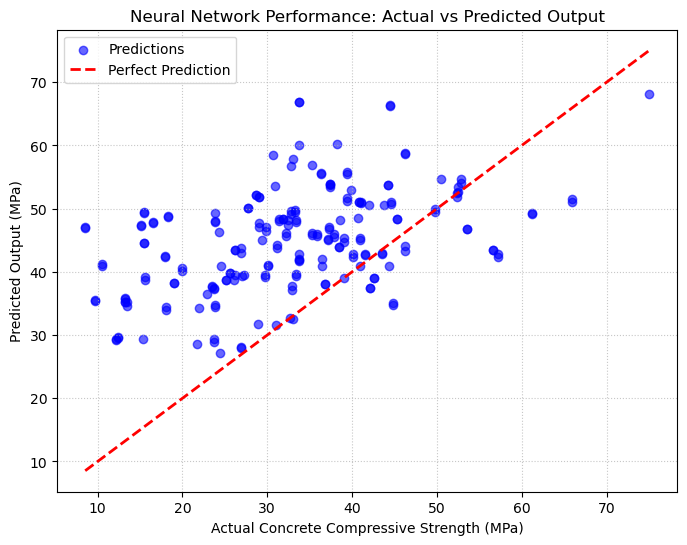

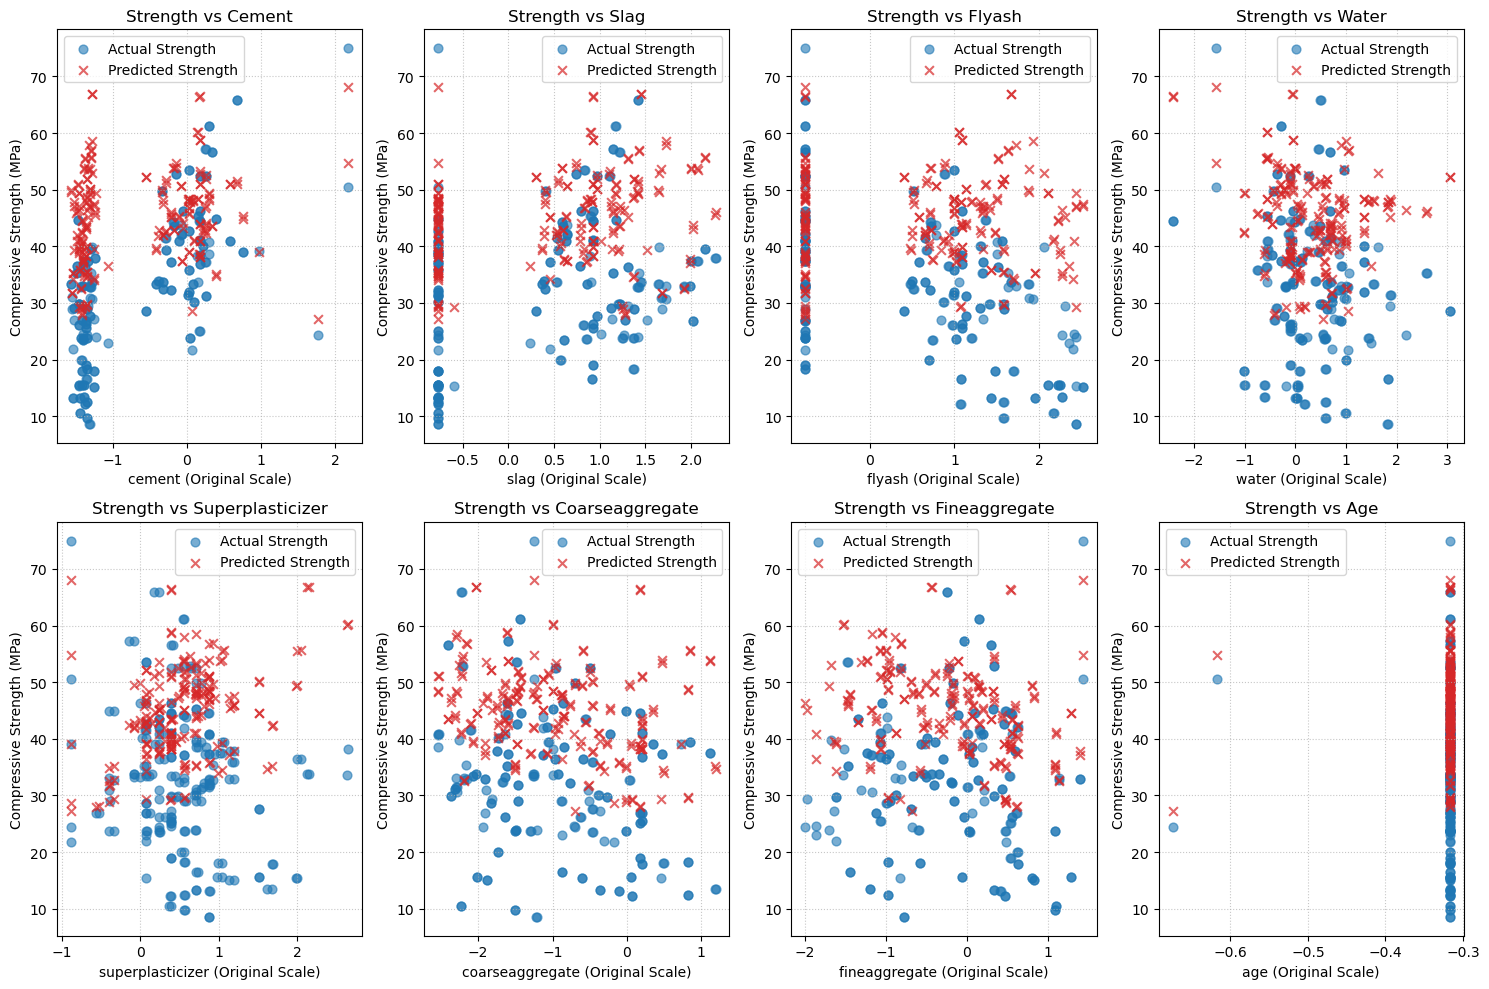

In [4]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from plot import plot

# ==========================================
# 步骤 1 & 2: 数据准备与预处理
# ==========================================

# 读取数据集
df = pd.read_csv('Concrete_Data_Yeh.csv')

# 提取8个输入变量和1个输出变量
# iloc方法是通过索引行、列的索引位置[index, columns]来寻找值
# 第一个参数为行，第二个参数为列
# csv文件的第一行为标签，不计入，df.iloc[0]即表示第2行的数据
X = df.iloc[:, :8].values  # 前8列为输入特征
y = df.iloc[:, 8].values.reshape(-1, 1)  # 第9列为输出特征 (抗压强度)
# 这里不加.values好像也行，加了返回array
# reshape把行向量转变为列向量，相当于转置
# 这是因为iloc[:, 8]破坏了列维度，使用iloc[:, 8:9]或iloc[:, 8:]即可保留列维度，不需要reshape

# a) 数据准备：将数据集的前80%作为训练集，后20%作为测试集
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=26)
# 似乎是一个内置函数，用于将按比例分割，不过似乎并不是前80%后20%的分割方法
# 查询后得知，random_state 参数是一个随机数种子，用于在分割前对数据进行洗牌，保证结果的可重复性
# shuffle 参数决定了是否在分割前对数据进行洗牌，默认为True，即进行洗牌
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
# 将shuffle置否即可实现前80%后20%的分割方法

# b) 数据预处理：使用标准化处理特征，确保输入数据在相同的量纲维度下，加速模型收敛
scaler = StandardScaler()
# StandardScaler 是一种常用的数据标准化方法，用于将数据转换为均值为 0，标准差为 1 的标准正态分布
# 均值为 0，标准差为 1 正确，但是否为正态分布未知
X_train_scaled = scaler.fit_transform(X_train)
# fit_transform 不仅计算训练数据的均值和方差，还会基于计算出来的均值和方差来转换训练数据，从而把数据转换成标准的正态分布
X_test_scaled = scaler.transform(X_test)
# transform 很显然，它只是进行转换，只是把测试数据转换成标准的正态分布。在fit的基础上，进行标准化，降维，归一化等操作
# fit 简单来说，就是求得训练集X的均值，方差，最大值，最小值,这些训练集X固有的属性
# 一般来说测试集使用fit_transform验证集使用transform
# 在测试集时已经收集了数据的均值和方差并且我们认为测试集和验证集数据收集的都足够充分，均值和方差一致，所以验证集不需要重新求均值和方差
# 也就是说transform是直接拿fit_transform训练好的参数去标准化别的数据集？原来标准化处理的时候就已经有训练了
# 自变量X进行了标准化处理，但因变量y并没有

# 将 NumPy 数组转换为 PyTorch 的 Tensor 格式
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)
# 经典pytorch，明显是要上神经网络了
# 我用了gpu版的2.10.0+cu126的pytorch

# ==========================================
# 步骤 3: 神经网络构建
# ==========================================

# c) 构建适合回归问题的神经网络模型，包含输入层(8)、多个隐藏层和输出层(1)
class ConcreteNet(nn.Module):
    def __init__(self):
        super(ConcreteNet, self).__init__()
        # 使用多个隐藏层和 ReLU 激活函数测试效果
        self.net = nn.Sequential(
            nn.Linear(8, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1) # 回归问题输出层不需要激活函数
        )
        # 8-64-32-1共四层，64后、32后加ReLU

    def forward(self, x): # 前向传播
        return self.net(x)

model = ConcreteNet()
# 实例化ConcreteNet
# 使用均方误差 (MSE) 作为损失函数
criterion = nn.MSELoss()
# 使用 Adam 优化器
optimizer = optim.Adam(model.parameters(), lr=0.01)
# lr是精度？

# ==========================================
# 步骤 4: 模型训练
# ==========================================

# d) 使用训练集对模型进行训练，通过反向传播算法更新权重和偏置
epochs = 500
# 当一个完整的数据集通过了神经网络一次并且返回了一次，这个过程称为一次epoch
train_losses = []

for epoch in range(epochs):
    model.train()
    # 开始训练模型？
    optimizer.zero_grad()           # 清空梯度

    outputs = model(X_train_t)      # 前向传播
    loss = criterion(outputs, y_train_t) # 计算损失

    loss.backward()                 # 反向传播
    optimizer.step()                # 更新权重参数

    train_losses.append(loss.item())
    # item()函数的主要用途是从单元素张量中提取元素值并返回，同时保持元素的类型不变
    # 看来 criterion 返回的是张量

    if (epoch + 1) % 100 == 0:
        # 每 100 epoch
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

# ==========================================
# 步骤 5: 模型测试、评估与可视化
# ==========================================

# e) 使用测试集评估模型，计算预测值与实际值之间的均方误差
model.eval() # 切换至评估模式
with torch.no_grad():
    # torch.no_grad 是 PyTorch 中的一个上下文管理器，它的主要作用是在某个指定的代码块中禁用梯度计算。
    # 这在进行模型推理或评估时非常有用，因为在这些情况下，我们通常不需要计算梯度，从而可以减少内存消耗和计算时间
    predictions = model(X_test_t)
    test_mse = criterion(predictions, y_test_t)

print(f"\nFinal Test Mean Squared Error (MSE): {test_mse.item():.4f}")

plot(X_test_t, y_test_t, predictions, df.columns[:8].tolist())

一次运行结果如下：\
Epoch [100/500], Loss: 124.4899\
Epoch [200/500], Loss: 98.9511\
Epoch [300/500], Loss: 59.0826\
Epoch [400/500], Loss: 33.0053\
Epoch [500/500], Loss: 23.7193

Final Test Mean Squared Error (MSE): 241.9081

![Figure_9.png](Figures/Figure_9.png)

![Figure_10.png](Figures/Figure_10.png)

神经网路相比线性回归收敛要快得多，下降速度也很快。由于没有进行相关性分析和主成分分析，哪怕使用强大的神经网络且对数据进行了归一化，最终效果也并不好，最终MSE高达100，图中的散点与红色的理想线符合得也不是很好。接下来进行相关性分析和主成分分析。

#### 4.2 高相关性特征的神经网络

Epoch [100/500], Loss: 135.9023
Epoch [200/500], Loss: 71.1484
Epoch [300/500], Loss: 54.2778
Epoch [400/500], Loss: 49.3695
Epoch [500/500], Loss: 47.1894

[Neural Network] Final Test MSE: 153.4599


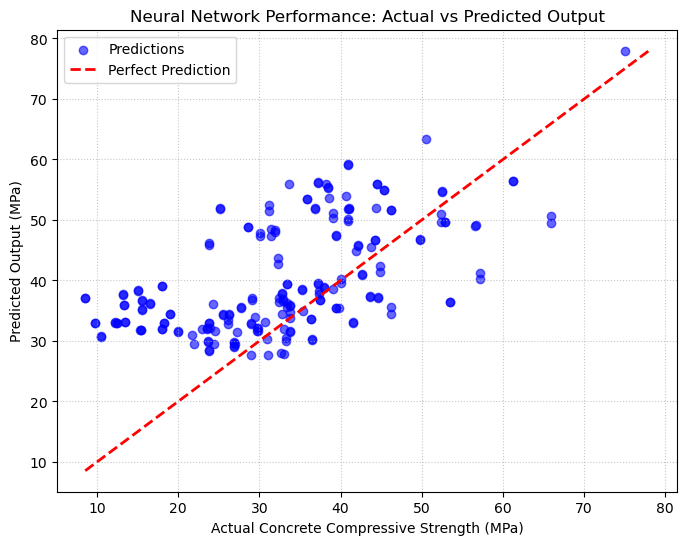

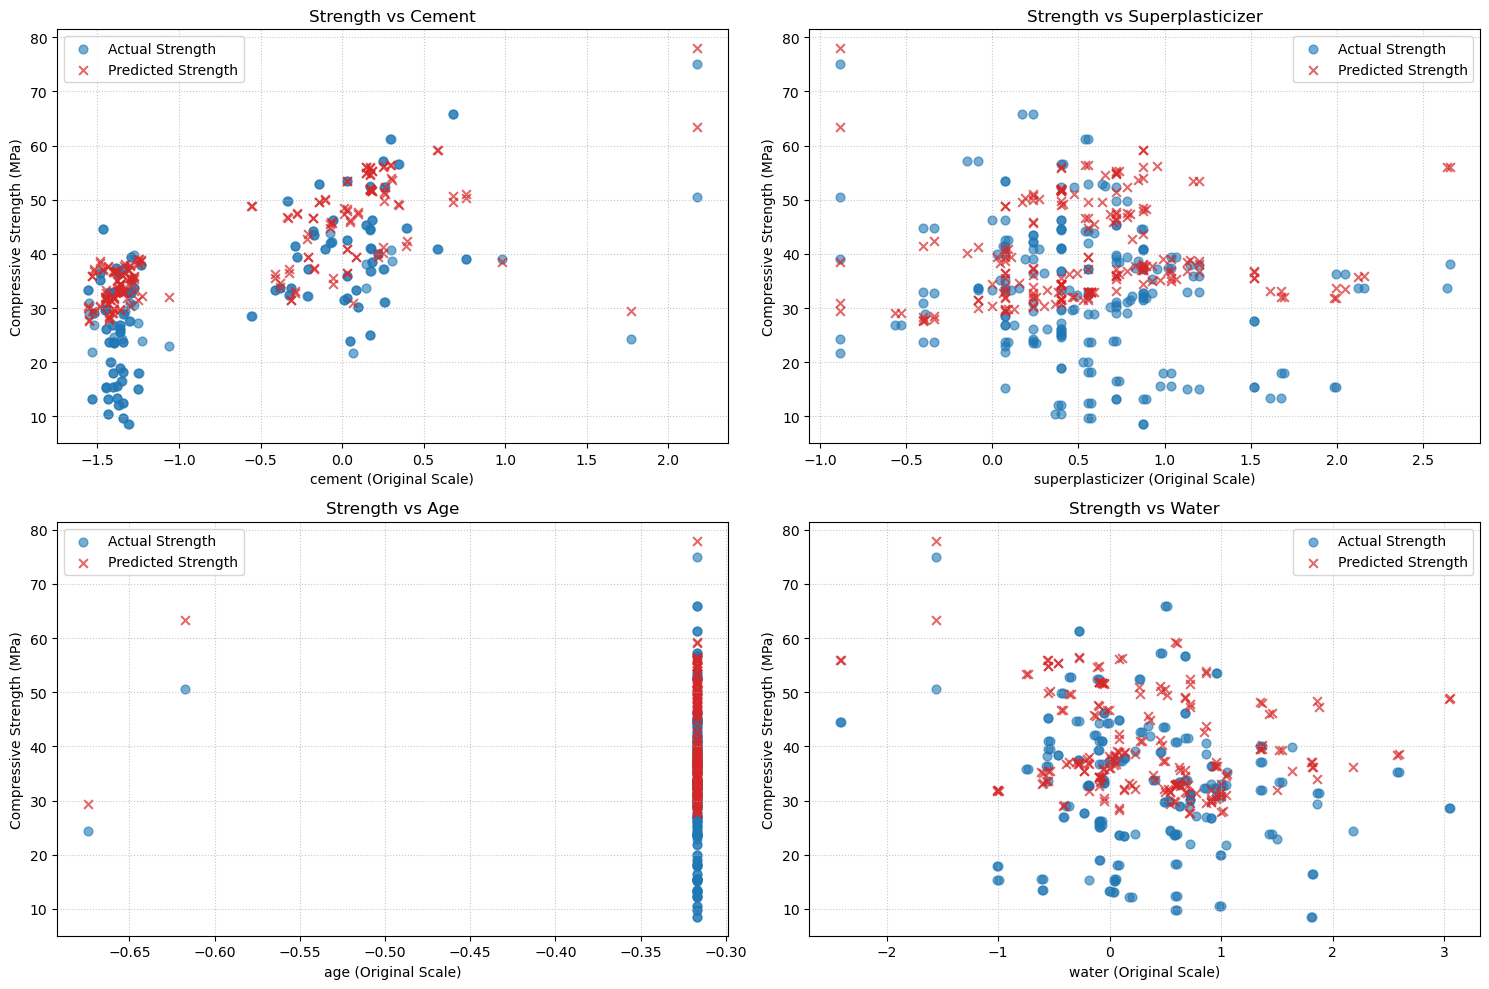

In [3]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from plot import plot

# ==========================================
# 步骤 1 & 2: 数据准备与特征选择
# ==========================================
df = pd.read_csv('Concrete_Data_Yeh.csv')

# 只选择相关性大于 0.2 的四个特征
selected_features = ['cement', 'superplasticizer', 'age', 'water']
X = df[selected_features].values
y = df['csMPa'].values.reshape(-1, 1)

# 数据集划分与标准化
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 转换为 PyTorch Tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

# ==========================================
# 步骤 3: 神经网络构建 (针对4维输入进行修改)
# ==========================================
class ConcreteNetSelected(nn.Module):
    def __init__(self):
        super(ConcreteNetSelected, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 64),  # 【关键修改】输入层维度改为 4
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

model = ConcreteNetSelected()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# ==========================================
# 步骤 4 & 5: 模型训练与测试
# ==========================================
epochs = 500
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

model.eval()
with torch.no_grad():
    predictions = model(X_test_t)
    test_mse = criterion(predictions, y_test_t)

print(f"\n[Neural Network] Final Test MSE: {test_mse.item():.4f}")

plot(X_test_t, y_test_t, predictions, selected_features)

一次运行结果如下：
Epoch [100/500], Loss: 147.0925\
Epoch [200/500], Loss: 64.0955\
Epoch [300/500], Loss: 49.7032\
Epoch [400/500], Loss: 47.4570\
Epoch [500/500], Loss: 45.5297

[Neural Network] Final Test MSE: 156.0480

![Figure_11.png](Figures/Figure_11.png)

![Figure_12.png](Figures/Figure_12.png)

发现相对4.1直接使用神经网络有了不小的精度提升。

#### 4.3 主成分分析后的神经网络

原始特征维度: 8
PCA 降维后维度 (解释90%方差): 6
各主成分方差贡献率: [0.28501242 0.17700935 0.16750988 0.12676986 0.1189385  0.09877443]
Epoch [100/500], Loss: 141.5581
Epoch [200/500], Loss: 106.2650
Epoch [300/500], Loss: 53.2049
Epoch [400/500], Loss: 41.7346
Epoch [500/500], Loss: 35.7111

[Neural Network] Final Test MSE: 49.3915


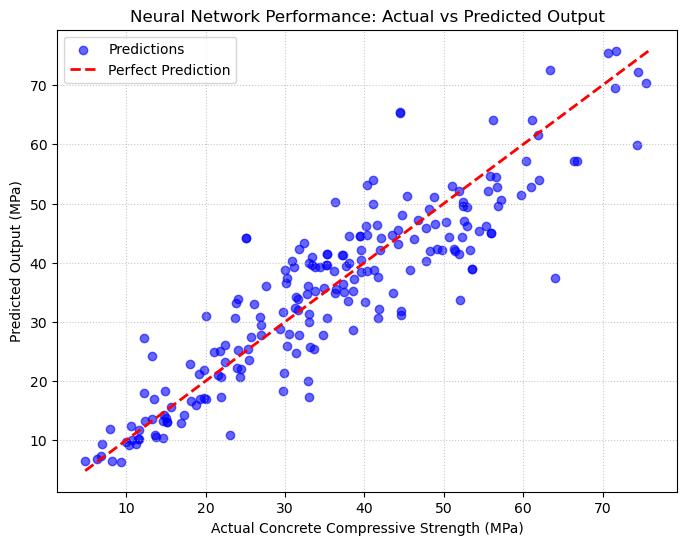

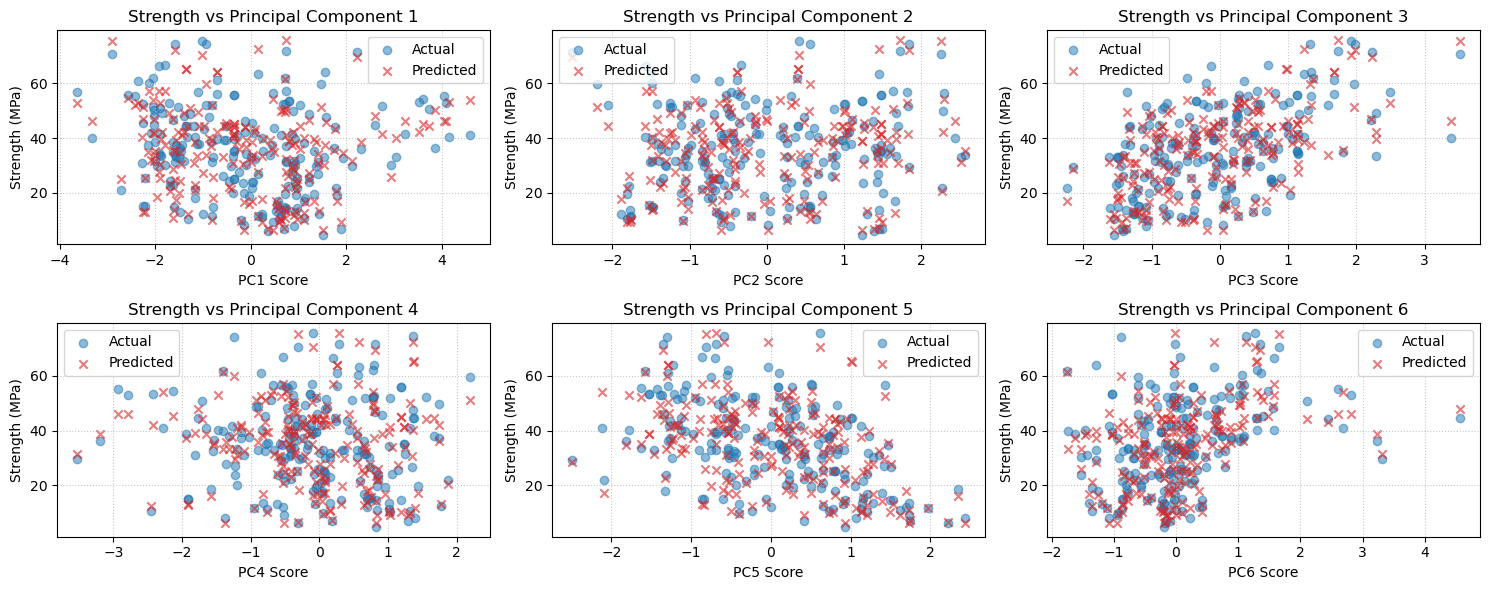

In [5]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import math

# 1. 加载数据
df = pd.read_csv('Concrete_Data_Yeh.csv')
X_raw = df.iloc[:, :8].values
y_raw = df['csMPa'].values.reshape(-1, 1)

# 2. 数据标准化 (PCA 必须步骤)
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X_raw)

# 3. 执行 PCA 降维
# 设置 n_components=0.90 表示自动选择能解释 90% 方差的主成分数量
pca = PCA(n_components=0.90)
X_pca = pca.fit_transform(X_scaled)
n_components = X_pca.shape[1]

print(f"原始特征维度: 8")
print(f"PCA 降维后维度 (解释90%方差): {n_components}")
print(f"各主成分方差贡献率: {pca.explained_variance_ratio_}")

# 4. 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X_pca, y_raw, test_size=0.2, random_state=42)

# 转换为 PyTorch 张量
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

# 5. 构建针对 PCA 输入的神经网络
class PCANet(nn.Module):
    def __init__(self, input_dim):
        super(PCANet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64), # 动态设置输入维度为 n_components
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

model = PCANet(n_components)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 6. 模型训练
epochs = 500
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

# 7. 模型评估与预测
model.eval()
with torch.no_grad():
    y_pred_t = model(X_test_t)
    y_pred = y_pred_t.numpy()
    test_mse = criterion(y_pred_t, y_test_t)

print(f"\n[Neural Network] Final Test MSE: {test_mse.item():.4f}")
# e) 绘图：将测试集的 target 与模型的 output 进行可视化比较
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='blue', label='Predictions')
# 散点图
# 细节将 tensor 转为 numpy 类型方便绘图

# 绘制 y=x 参考线 (完美预测线)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

plt.title('Neural Network Performance: Actual vs Predicted Output')
plt.xlabel('Actual Concrete Compressive Strength (MPa)')
plt.ylabel('Predicted Output (MPa)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

# 8. 自动布局绘制主成分与预测值的关系图
def plot_pca_results(X_pca_test, y_actual, y_predicted):
    n_feat = X_pca_test.shape[1]
    n_rows = 2
    n_cols = math.ceil(n_feat / n_rows)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 2 * n_cols))
    axes_flat = axes.flatten() if n_feat > 1 else [axes]

    for i in range(n_feat):
        ax = axes_flat[i]
        pc_data = X_pca_test[:, i]

        ax.scatter(pc_data, y_actual, color='#1f77b4', alpha=0.5, label='Actual', marker='o')
        ax.scatter(pc_data, y_predicted, color='#d62728', alpha=0.6, label='Predicted', marker='x')

        # 设定 X 轴范围
        x_min, x_max = pc_data.min(), pc_data.max()
        margin = (x_max - x_min) * 0.05
        ax.set_xlim(x_min - margin, x_max + margin)

        ax.set_title(f'Strength vs Principal Component {i+1}')
        ax.set_xlabel(f'PC{i+1} Score')
        ax.set_ylabel('Strength (MPa)')
        ax.legend()
        ax.grid(True, linestyle=':', alpha=0.7)

    # 关闭多余的子图
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].axis('off')

    plt.tight_layout()
    plt.show()

plot_pca_results(X_test, y_test, y_pred)

运行结果如下：

原始特征维度: 8\
PCA 降维后维度 (解释90%方差): 6\
各主成分方差贡献率: [0.28501242 0.17700935 0.16750988 0.12676986 0.1189385  0.09877443]\
Epoch [100/500], Loss: 135.0353\
Epoch [200/500], Loss: 103.6407\
Epoch [300/500], Loss: 46.1802\
Epoch [400/500], Loss: 38.8469\
Epoch [500/500], Loss: 33.2897

[Neural Network] Final Test MSE: 46.1276


![Figure_13.png](Figures/Figure_13.png)

![Figure_14.png](Figures/Figure_14.png)

发现相对4.2也有了不小的精度提升，效果最好

### 5 附录

#### 5.1 plot.py

In [ ]:
import math
import matplotlib.pyplot as plt

# 确保此时你有以下变量：
# X_test: 原始未标准化的测试集特征矩阵 (为了横坐标有实际物理意义)
# y_test: 真实的测试集输出
# y_pred: 模型对测试集的预测输出
# selected_features: ['cement', 'superplasticizer', 'age', 'water']

def plot(X_test, y_test, y_pred, selected_features):
    # e) 绘图：将测试集的 target 与模型的 output 进行可视化比较
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_pred.numpy(), alpha=0.6, color='blue', label='Predictions')
    # 散点图
    # 细节将 tensor 转为 numpy 类型方便绘图

    # 绘制 y=x 参考线 (完美预测线)
    min_val = min(y_test.min(), y_pred.numpy().min())
    max_val = max(y_test.max(), y_pred.numpy().max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

    plt.title('Neural Network Performance: Actual vs Predicted Output')
    plt.xlabel('Actual Concrete Compressive Strength (MPa)')
    plt.ylabel('Predicted Output (MPa)')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.show()

    n_features = len(selected_features)
    n_rows = 2  # 你可以根据喜好设置为 2 或 3
    n_cols = math.ceil(n_features / n_rows)

    # 创建一个 2x2 的画布，共 4 张子图
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 8))
    axes = axes.flatten() # 将二维的轴矩阵展平，方便遍历

    for i, feature in enumerate(selected_features):
        ax = axes[i]

        # 获取当前特征在测试集中的原始数值
        # 散点图不需要对数据进行排序，直接映射即可
        x_feature_raw = X_test[:, i]

        # 绘制真实值 (蓝色圆点，s为点的大小)
        ax.scatter(x_feature_raw, y_test, color='#1f77b4', alpha=0.6, label='Actual Strength', marker='o', s=40)

        # 绘制预测值 (红色叉号，使用不同形状避免颜色重叠时看不清)
        ax.scatter(x_feature_raw, y_pred, color='#d62728', alpha=0.7, label='Predicted Strength', marker='x', s=40)

        # 设置图表元素
        ax.set_title(f'Strength vs {feature.capitalize()}')
        ax.set_xlabel(f'{feature} (Original Scale)')
        ax.set_ylabel('Compressive Strength (MPa)')
        ax.legend()
        ax.grid(True, linestyle=':', alpha=0.7)

        x_min, x_max = x_feature_raw.min(), x_feature_raw.max()
        x_margin = (x_max - x_min) * 0.05
        ax.set_xlim(x_min - x_margin, x_max + x_margin)

    # 自动调整子图间距
    plt.tight_layout()
    plt.show()